In [30]:
from langgraph.graph import StateGraph
from typing import List,TypedDict

In [31]:
class AgentState(TypedDict):
    name: str
    age : str
    skills: List[str]
    final: str

In [32]:
def node1(state : AgentState) -> AgentState:
    state['final'] = f"{state['name']}, welcome to the system! "
    return state

In [33]:
def node2(state : AgentState) -> AgentState:
    state['final'] = state['final'] + f"you are {state['age']} years old! "
    return state

In [34]:
def node3(state : AgentState) -> AgentState:
    state['final'] = state['final'] + f"you have skills in {state['skills']} "
    return state

In [35]:
graph = StateGraph(AgentState)

graph.add_node("greeting" , node1)
graph.add_node("age" , node2)
graph.add_node("information" , node3)

graph.set_entry_point("greeting")
graph.add_edge("greeting" , "age")
graph.add_edge("age" , "information")
graph.set_finish_point("information")

app = graph.compile()

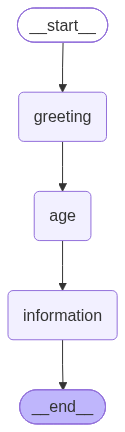

In [36]:
app

In [42]:
input = {
    'name': "Bishoy",
    'age': 22,
    'skills': ["Machine Learning","Deep Learning","Agents"]
    }

app.invoke(input)

{'name': 'Bishoy',
 'age': 22,
 'skills': ['Machine Learning', 'Deep Learning', 'Agents'],
 'final': "Bishoy, welcome to the system! you are 22 years old! you have skills in ['Machine Learning', 'Deep Learning', 'Agents'] "}